## An Example of Model Fitting

This notebook is to accompany the tutorial of model-based NMR quantification with the nmrQuant software.

In [1]:
# Initialization
%reset -f
%load_ext autoreload
%autoreload 2
%matplotlib inline
%matplotlib  notebook
%precision 4

# Add the main software directory to the path
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # By default it is the parent directory

# Import necessary modules
import numpy as np
import pandas as pd
from chemTree import *
from MainLogic import *
from MainLogic import Workspace, Series, Datum
import matplotlib.pyplot as plt
from matplotlib import cm, rcParams
from dataio import read_any_file
from pprint import pprint

# Set up display parameters
rcParams['figure.max_open_warning'] = 50
rcParams.update({'font.size': 10})
rcParams['ps.fonttype'] = 42               # Output TrueType font; Needed to be able to save figures in .eps format
rcParams['pdf.fonttype'] = 42
rcParams['pdf.use14corefonts'] = True

### 1. Load the Data

In [2]:
# Create a new Workspace
wsp = Workspace(HCmode='1H')

In [3]:
# 1. Add first Series with two Spinsolve spectra
ser1 = wsp.addSeries(name = 'Series 1')

# Read the FID (yT), array of time stamps (t), and dictionary of acquisition parameters (dic)
t, yT, dic = read_any_file('data_tutorial\S20.10\data.1d')

# Set the parameters in the Series
ser1.c0, ser1.f0, ser1.t = dic['c0'], dic['f0'], t
ser1.fullReset()

# Add the first spectrum
ser1.addDatum(yT, name=dic['name'])
# Add the second sepectrum (assuming the same parameters)
t, yT, dic = read_any_file(os.path.join('data_tutorial', 'S20.11', 'data.1d'))
dat1 = ser1.addDatum(yT, name=dic['Sample'])
print(dat1)

Dataset S20.11 in Series 1


In [4]:
# 2. Add the second Series with an array of Spinsolve files
ser2 = wsp.addSeries(name = 'Series 2')

for i in range(9):
    dirname = 'data_tutorial\S20.13.{:d}'.format(i)
    t, yT, dic = read_any_file(os.path.join(dirname, 'data.1d'))
    
    # Set the acquisition parameters in the Series
    if i == 0:
        ser2.c0, ser2.f0, ser2.t = dic['c0'], dic['f0'], t
        ser2.fullReset()
    
    # Determine the time stamp and use it to as an array value (useful for RM)
    timeString, ms = dic['startTime'].split('.')
    startTime = time.mktime(time.strptime(timeString, '%Y-%m-%dT%H:%M:%S')) + int(ms)/1000         # Time in sec from the start of epoch
    if i == 0: timeOffset = startTime         # Initial time stamp will be subtracted from the rest of the files

    # Add new Datum
    print('Adding file {} acquired at {}'.format(dirname, timeString))
    ser2.addDatum(yT, name=dic['name'], arrVal=startTime-timeOffset)

Adding file data_tutorial\S20.13.0 acquired at 2021-06-22T13:22:36
Adding file data_tutorial\S20.13.1 acquired at 2021-06-22T13:28:10
Adding file data_tutorial\S20.13.2 acquired at 2021-06-22T13:33:43
Adding file data_tutorial\S20.13.3 acquired at 2021-06-22T13:39:28
Adding file data_tutorial\S20.13.4 acquired at 2021-06-22T13:45:26
Adding file data_tutorial\S20.13.5 acquired at 2021-06-22T13:50:30
Adding file data_tutorial\S20.13.6 acquired at 2021-06-22T13:56:14
Adding file data_tutorial\S20.13.7 acquired at 2021-06-22T14:01:44
Adding file data_tutorial\S20.13.8 acquired at 2021-06-22T14:10:24


Display the contents of the Workspace. The numbers <i,j> correspond to the indices of each Datum in the Workspace and allow one to access it as ```dat = wsp.series[i].data[j]``` or simply ```wsp[i,j]```. To determine the index of a given Datum instance, use ```i,j = dat.selfID()```.

In [5]:
print(wsp)
dat = wsp[1,3]

print(dat)

Workspace
|------	Series 1
	|------<0,0> S20.10
	|------<0,1> S20.11
	Series 2
	|------<1,0> S20.13.0
	|------<1,1> S20.13.1
	|------<1,2> S20.13.2
	|------<1,3> S20.13.3
	|------<1,4> S20.13.4
	|------<1,5> S20.13.5
	|------<1,6> S20.13.6
	|------<1,7> S20.13.7
	|------<1,8> S20.13.8

Dataset S20.13.3 in Series 2


### 2. Initial Preprocessing
Set zero-filling and apodization; this is set for an entire Series. The new spectra will have the length ```nf=nt*(2^zff)```, where nt is the length of FID; ```apod``` defines the parameter of the exponential line-broadening window.

In [6]:
ser1.resetFreqs(zff=1, apod=0.5)

Perform the phasing of the spectra using an automated algorithm. If only zero-order phasing is desired, this can be selected with the option ```fit_Ph1=False```.

In [7]:
dat = wsp[1,3]
dat.auto_phase(fit_Ph1=False)

AutoPhase
Optimization terminated successfully.
         Current function value: 0.145890
         Iterations: 17
         Function evaluations: 34


## 3. Building a chemTree Model
Add several chemicals to the model from the exisiting chemical library.

In [8]:
# Display the contents of the chemical library
pprint(chemLib)

# Save the entire chem library as an Excel file
writeChemLib_XLSX(chemLib, 'chemLibrary_saved.xlsx')

{'Built-in models': {'Chloroform': <chemTree.chemSpec object at 0x000001AA17C13608>,
                     'Ethanol': <chemTree.chemSpec object at 0x000001AA1A968708>,
                     'TMS': <chemTree.chemSpec object at 0x000001AA1A968208>,
                     'TMSP': <chemTree.chemSpec object at 0x000001AA1A968388>,
                     'Water': <chemTree.chemSpec object at 0x000001AA1A968188>},
 'ESR': {'Amino-2-propanol': <chemTree.chemSpec object at 0x000001AA1AEB3488>,
         'Cannabidiol (CBD)': <chemTree.chemSpec object at 0x000001AA1B0BB248>,
         'Cannabidiolic acid (CBDa)': <chemTree.chemSpec object at 0x000001AA1B0C3148>,
         'Cannabinol (CBN)': <chemTree.chemSpec object at 0x000001AA1B0C7148>,
         'Methylsulfonylmethane': <chemTree.chemSpec object at 0x000001AA1AEB3B88>,
         'N-Isopropylbenzylamine': <chemTree.chemSpec object at 0x000001AA1B0B2388>,
         'Phenethylamine': <chemTree.chemSpec object at 0x000001AA1B0B2E88>,
         'Propylene gly

Saving Other/MDEA
Saving Other/MEG
Saving Other/MGO Dihydrate
Saving Other/MGO Monohydrate
Saving Other/MSN
Saving Other/Methanol
Saving Other/Methyl acetate
Saving Other/Propane (Gas Phase)
Saving Other/Propanol
Saving Other/Singlet
Saving Other/Tetrahydrocannabinoic acid (THCa)
Saving Other/cis-2-Butene-1,4-diol
Saving Other/test
Saving Elmar_EvA/EvA02
Saving Elmar_EvA/EvA34
Saving Elmar_EvA/b,g-EvA34
Saving Elmar_EvA/b-EvA02
Saving Elmar_EvA/b-EvA34
Saving Elmar_EvA/g-EvA34
Saving Sugars/Lactose
Saving Sugars/Maltose
Saving Sugars/Mannitol
Saving Sugars/Sorbitol
Saving Sugars/Sucrose
Saving Sugars/Sucrose-F
Saving Sugars/Sucrose-G
Saving Sugars/Xylitol
Saving Sugars/alpha-Fructofuranose
Saving Sugars/alpha-Fructopyranose
Saving Sugars/alpha-Galactopyranose
Saving Sugars/alpha-Glucopyranose
Saving Sugars/beta-Fructofuranose
Saving Sugars/beta-Fructopyranose
Saving Sugars/beta-Galactopyranose
Saving Sugars/beta-Glucopyranose
Saving PubChem SDF/Ascorbic acid
Saving PubChem SDF/Citric a

In [9]:
# Create an instant of a chemNode
newNode = chemNodeQM('Water')

# Add it to the root of chemTree in the Workspace
wsp.addTreeNode(newNode)

# Add a group node.
newGroupNode = chemNode('Vitamins')
wsp.addTreeNode(newGroupNode)
# Children nodes can be added to the group in two ways:
# 1. Directly to the group
newGroupNode.addChild(chemNodeQM('Thiamine'))
# 2. Via addTreeNode method
wsp.addTreeNode(chemNodeQM('Pyridoxine'), prntName='Vitamins')

# Add more species
wsp.addTreeNode(chemNodeQM('Glycerol'))
wsp.addTreeNode(chemNodeQM('Maleic acid'))
wsp.addTreeNode(chemNodeQM('TMSP'))

True

Some of the nodes in the chemTree need to be designated as 'reported' (they may represent chemicals, their groups, or distinct peaks). The models generated by these nodes will be used for quantification, and their intensities will be estimated and reported in the results. The order of the component intensities in the results arrays corresponds to the order in the repRootNames list.

In [10]:
# Set a node as reported.
# Both Thiamine and Pyridoxine will be quantified as a group with fixed relative intensities (e.g. 1:4).
wsp.setRepRoot('Vitamins', True)
wsp.T['Thiamine'].intn = 0.2
wsp.T['Pyridoxine'].intn = 0.8

print('Reported nodes: {}\n'.format(wsp.repRootNames))

# Quantify separately
wsp.setRepRoot('Vitamins', flag=False)
wsp.setRepRoot('Thiamine', flag=True)

print('Reported nodes: {}'.format(wsp.repRootNames))

Reported nodes: ['Water', 'Vitamins', 'Glycerol', 'Maleic acid', 'TMSP']

Reported nodes: ['Water', 'Thiamine', 'Pyridoxine', 'Glycerol', 'Maleic acid', 'TMSP']


Display the chemTree. This will print out all nodes existing in the tree, including those that correspond to individual peaks (or groups of peaks), e.g. Thiamine-3.2 is the second goup of peaks in the third spin system of thiamine.

In [11]:
pprint(wsp.T)

Mixture
	|------Water
		|------Water-1.1 (Water H_water)
	|------Vitamins
		|------Thiamine
			|------Thiamine-1.1 (Thiamine H18)
			|------Thiamine-2.1 (Thiamine H9)
			|------Thiamine-3.1 (Thiamine H3)
			|------Thiamine-3.2 (Thiamine H2)
			|------Thiamine-4.1 (Thiamine H10)
			|------Thiamine-5.1 (Thiamine H12)
		|------Pyridoxine
			|------Pyridoxine-1.1 (Pyridoxine H7)
			|------Pyridoxine-2.1 (Pyridoxine H11)
			|------Pyridoxine-3.1 (Pyridoxine H6)
			|------Pyridoxine-4.1 (Pyridoxine H9)
	|------Glycerol
		|------Glycerol-1.1 (Glycerol H1a)
		|------Glycerol-1.2 (Glycerol H1b)
		|------Glycerol-1.3 (Glycerol H2)
	|------Maleic acid
		|------Maleic acid-1.1
	|------TMSP
		|------TMSP-1.1



Next cell demonstrates how a (sub)tree can be saved as a file, removed from the chemTree, and loded from a file.

In [12]:
# Save a Vitamins subtree in a file
saveTree('data_tutorial\Vitamins.ctr', wsp.getTree('Vitamins'))

# Remove the subtree from the workspace
wsp.delTreeNode('Vitamins')

# Insert a subtree from file
subTree = loadTree('data_tutorial\Vitamins.ctr')
wsp.addTreeNode(subTree)

True

All node in the chemTree must have distinct names. If there is a need to include a model of the same species multiple times (e.g. to fit similar isomers with slightly different chemical shifts), different names must be given to the corresponding nodes.

In [13]:
# Rename a chemTree node
wsp.renameTreeNode(oldName='Thiamine', newName='Vitamin B1')

# Revert the changes
wsp.renameTreeNode(oldName='Vitamin B1', newName='Thiamine')

Certain components can be excluded from fit for specific Datum or Series, if it is known that they are absent in the sample. This is not necessary, as their intensity would normally be estimated as 0, but it is recommended to include only the relevant components to improve the robustness of the model.

In [14]:
# Exclude glycerol from fit in the second Datum
wsp[0,1].setXclRootName('Glycerol', flag=True)

# Exclude maleic acid from fit in the first Series
wsp[0].setXclRootName('Maleic acid', flag=True)

# Display excluded nodes
print('Excluded nodes: ', wsp[0,1].xclRootNames)

Excluded nodes:  {'Maleic acid', 'Glycerol'}


## 4. Setting Frequency Blocks for  Optimization
The models can be fitted to the experimental data in the entire range of the spectrum (or on the entire legth of the FID, if the fitting is performed in time domain). However, we found it useful to restrict the optimization range to smaller frequency blocks (possibly disjoint or overlapping) that cover the most important regions of interest in the spectrum. The following commands define such frequency blocks to be used later during optimization. The definitions of the frequency blocks are shared among all Datums in a Series. Each block is referred to by its index (in the order of definition), with 0 reserved for the entire frequency range; if a block from the middle of the list is removed, the indices of the following blocks in the list will decrease by 1.

In [15]:
# Add new frequency blocks
ser1.addFreqBlock(lims=(-1.0, 9.0), select=True)      # Block 1. All peaks
ser1.addFreqBlock(lims=(-0.3, 0.3), select=True)      # Block 2. TMSP
ser1.addFreqBlock(lims=(2.0, 4.25), bslnOrder=1, select=False)  # Block 3.
ser1.addFreqBlock(lims=(6.0, 7.0))                    # Block 4.

# Remove the last frequency block
ser1.remFreqBlock(indx=4)

# Display all frequency blocks in a Series
ser1.showFreqBlocks()

indx=0, range of chemical shifts: Entire range ppm
indx=1, range of chemical shifts: -1.00 ... 9.00 ppm
indx=2, range of chemical shifts: -0.30 ... 0.30 ppm
indx=3, range of chemical shifts: 2.00 ... 4.25 ppm


## 5. Specying Model Parameters
Each model parameter (chemical shift, relaxation rate, J-coupling value, etc.) is characterised by its prior distribution that specifies minimum, mximum, and default values of the parameter, as well as the type of distribution and any hyperparameters if applicable. The specification of priors follows the same rules as the definitions of chemical shifts and J-couplings in the chemical database.

The parameters are typically referred to and can be accessed on a Datum level by their names represented as 3-tuples of (str, str, int) in the following format: ('Node name', 'Parameter type', Parameter index).

The first position in the tuple is name of any node in the chemTree; furthermore, if a parameter is related to the spectrum processing rather than a model (e.g. phasing), this position should hold '.'. The choises for second postion include 'chsh' and 'alph' for chemical shifts and relaxation rates applied globally to an entire chemical or a group thereof, 'chshQD', 'alphQD', and 'jcplQD' for parameters used in the quantum mechanical specification of the spin system (these are the usual spin chemical shifts and J couplings), as well as 'theta', 'tau', and 'sigma2' for the values of the zeroth-, first-order phasing parameters, and the variance of noise repectively (these are to be used with '.'). Finally, the third position is relevant if a node is characterised by an array of parameters of the same type (e.g. several spin chemical shifts as in most cases), in which case, it holds the index of the specific parameter (starting with 0). This can be relevant only for the quantum mechanical parameters. For single parameters (e.g. 'chsh', 'alph', 'theta', etc.), the index is to set to 0 by convention.

Examples of parameter keys:<br>
```('Mixture', 'chsh', 0)``` - the 'global' chemical shift that affects the entire spectrum<br>
```('Thiamine', 'alph', 0)``` - the relaxation rate for all peaks of Thiamine<br>
```('Water', 'ampl', 0)``` - the estimated intensity of water (only for reported nodes)<br>
```('Pyridoxine', 'chshQD', 2)``` - the chemical shift of a specific peak of Pyridoxine (H6)<br>
```('.', 'theta', 0)``` - zero-order phasing<br>
```('.', 'sigma2', 0)``` - variance of the noise (used to estimate the uncertainty)

In [16]:
# Set default value and alter the range for a specific Datum
key = ('Mixture', 'chsh', 0)
dat.setPrior(key, dval=-0.01, min=-0.05, max=0.05, label='Global')

# Display the specification
print('Parameter {} specified for {} is:\n{}\n'.format(key, dat, dat.getPrior(key)))

# Specify parameter prior for all data in a Series
key = ('Thiamine', 'jcplQD', 0)
ser1.setPrior(key, min=5.0, max=6.0, dval=5.75, label='H2-H3')

# Display the specification
dat = ser1.data[0]
print('Parameter {} specified for {} is:\n{}\n'.format(key, dat, dat.getPrior(key)))

Parameter ('Mixture', 'chsh', 0) specified for Dataset S20.13.3 in Series 2 is:
parsSpec(min=-0.05, max=0.05, label='Global', distr='Uniform', p1=None, p2=None, dval=-0.01)

Parameter ('Thiamine', 'jcplQD', 0) specified for Dataset S20.10 in Series 1 is:
parsSpec(min=5.0, max=6.0, label='H2-H3', distr='Uniform', p1=None, p2=None, dval=5.75)



## 6. Model Fitting
First, we discuss how the values of model parameters can be set manually, and then show how to estimate them using the optimization procedure.

In [17]:
# Set a parameter value manually
key=('Mixture', 'chsh', 0)
dat.setCrntVal(key, val=0.015)

# Display the current parameter value
val = dat.getCrntVal(key)
print('Parameter {} has value {:.3f} in {}.'.format(key, val, dat))

Parameter ('Mixture', 'chsh', 0) has value 0.015 in Dataset S20.10 in Series 1.


To evaluate the model with the currently set parameters use the method ```dat.evaluate()```. It returns two variables, first the value of the objective function (the lieklihood fucntion or the posterior distribution), and second, a dictionary of meta-information, which contains the specifications of marginalised posterior distributions (if applicable for certain parameters).

In [18]:
# Reevaluate the model with the current parameter values and estimate the fitting score
cfun_value, meta = dat.evaluate()
print('The value of the cost function is {:.4f}\n'.format(cfun_value))
print('The estimated intensities of model components are:')
for name, val in dat.report_results().items():
    print('{} : {:.4f}'.format(name, val))

The value of the cost function is -37648.5913

The estimated intensities of model components are:
Water : 103.9550
Glycerol : 0.0000
TMSP : 0.1115
Thiamine : 4.6089
Pyridoxine : 0.6588


In the following cell, the optimization fucntion is used to find the optimal parameter value for the global chemical shift. This requires setting a list of parameters to optimize with the non-linear least squares optimization routine, ```parsKeys```. 

Additionally, one may specify ```autoKeys``` - parameters, whose values will be found using a closed form expression if possible, e.g. amplitudes with Gaussian priors, variance of noise, and the zero-order phasing. The values of all parameters in ```autoKeys``` will be updated even if they are not listed in ```parsKeys```. To reevaluate _all_ parameters whose estimation is possible in closed form, use ```autoKeys='All'```; to keep the values of all parameters, use ```autoKeys=[]```; by default, ```autoKeys=None```, which will use selected parameters from the last Step in the current Series.

Another optional argument to pass to the optimization function is a list of frequency blocks, ```frqBlkIds```, in which to fit the model. This allows us to restrict the fitting domain and is especially useful when peaks of verying intensities are present in the spectrum. The list passed in this argument should contain the indices of optimization frequency blocks, as defined earlier.

In [19]:
# Set up lists of parameters to optimize
parsKeys = [('Mixture', 'chsh', 0)]
autoKeys = [('.', 'sigma2', 0), ('TMSP', 'ampl', 0)]

# Run the optimization algorithm with the selected autoKeys
dat.optimize(parsKeys, autoKeys=autoKeys, frqBlkIds=[1,2]);

# Alternatively, estimate all parameters in closed form, if possible
dat.optimize(parsKeys, autoKeys='All', frqBlkIds=[1,2]);

# Optimize multiple parameters simultaneously; use multiple basinhopping steps to avoid local optima
dat.optimize(parsKeys=[('Mixture', 'chsh', 0), ('Mixture', 'alph', 0)], \
             frqBlkIds=[1,2], nhop=3);

Fitting one parameter; 2 parameters inferred in closed form...
Optimization finished. Posterior=-3.761e+04
Found values:
     ('Mixture', 'chsh', 0) = 0.01372


Fitting one parameter; 6 parameters inferred in closed form...
Optimization finished. Posterior=-3.761e+04
Found values:
     ('Mixture', 'chsh', 0) = 0.01372


Fitting 2 parameters; 6 parameters inferred in closed form...
basinhopping step 0: f 36600.1
basinhopping step 1: f 36600.1 trial_f 39116.6 accepted 0  lowest_f 36600.1
basinhopping step 2: f 36600.1 trial_f 39116.6 accepted 0  lowest_f 36600.1
basinhopping step 3: f 36600.1 trial_f 39116.6 accepted 0  lowest_f 36600.1
Optimization finished. Posterior=-3.66e+04
Found values:
     ('Mixture', 'alph', 0) = 4.4281
     ('Mixture', 'chsh', 0) = 0.014984




To automate the routine analysis, it is advised to define a sequence of processing steps, with each step encompassing a certain model fitting operation.

In [20]:
# Clear the existing processing steps
ser1.steps.clear()

# Fit the global chemical shift and peak width
ser1.steps.append(Step(parsKeys=[('Mixture', 'chsh', 0), ('Mixture', 'alph', 0)], \
                      autoKeys = [('.', 'sigma2', 0), ('Water', 'ampl', 0)], \
                      frqBlkIds=[1, 2], nrep=3, fitEach=True, nhop=3))

# Fit the TMSP peak
ser1.steps.append(Step(parsKeys=[('TMSP', 'chshQD', 0), ('TMSP', 'alphQD', 0)], \
                      autoKeys = [('.', 'sigma2', 0), ('TMSP', 'ampl', 0)], \
                      frqBlkIds=[2], nrep=1, fitEach=True))

# Add a custom function to be run on a third step
def custom_script(dat):
    """A custom function to be called during a processing step.
    
    Arguments:
        dat : Datum instance
            An instance of the Datum class which will be modified 
            on this step. Have access to all attributes and methods.
    """
    
    print('Running a custom script with {}...\n'.format(dat))
    
ser1.steps.append(Step(script=custom_script))

# Fit the Thiamine triplets
ser1.steps.append(Step(parsKeys=[('Thiamine', 'chshQD', 2), ('Thiamine', 'chshQD', 3)], \
                      frqBlkIds=[3], nrep=3, fitEach=False, nhop=3))

# Execute the defined steps
dat.run_steps()

Fitting one parameter; 2 parameters inferred in closed form...
Optimization finished. Posterior=-3.66e+04
Found values:
     ('Mixture', 'alph', 0) = 4.3566


Fitting one parameter; 2 parameters inferred in closed form...
Optimization finished. Posterior=-3.66e+04
Found values:
     ('Mixture', 'chsh', 0) = 0.014946


Fitting 2 parameters; 2 parameters inferred in closed form...
basinhopping step 0: f 36600.1
basinhopping step 1: f 36600.1 trial_f 36600.1 accepted 1  lowest_f 36600.1
found new global minimum on step 1 with function value 36600.1
basinhopping step 2: f 36600.1 trial_f 36600.1 accepted 1  lowest_f 36600.1
basinhopping step 3: f 36600.1 trial_f 36600.1 accepted 1  lowest_f 36600.1
Optimization finished. Posterior=-3.66e+04
Found values:
     ('Mixture', 'alph', 0) = 4.4283
     ('Mixture', 'chsh', 0) = 0.014984


Fitting one parameter; 2 parameters inferred in closed form...
Optimization finished. Posterior=-3.66e+04
Found values:
     ('Mixture', 'alph', 0) = 4.3592


Fi

Found model parameters can be copied between the Datums; likewise the sequence of steps can be copied to another Series.

In [21]:
# Choose which parameters to copy
dat = wsp[0,0]
keys = dat.allParsKeys()

# Copy parameter specifications
pars = {key : dat.getPrior(key) for key in keys}

# Copy parameter values
vals = {key : dat.getCrntVal(key) for key in keys}

# Update the parameter specifications and values in a new Datum
dat = wsp[0,1]
for key in keys:
    dat.setCrntVal(key, vals[key])
    dat.setPrior(key, pars[key])

In [22]:
# Copy all settings (frequency blocks, priors, and steps) from ser1 to ser2
ser2.copySettings(serFrom=ser1)

## Saving and Loading a Workspace

In [23]:
# Save the Workspace to a file
save_workspace(filename='workspaces\\tutorial_saved.wsp', wsp=wsp)

# Load an existing workspace
wsp, GUIsettings = load_workspace(filename='workspaces\\tutorial-step_7.wsp')

## Plot the spectrum

<IPython.core.display.Javascript object>


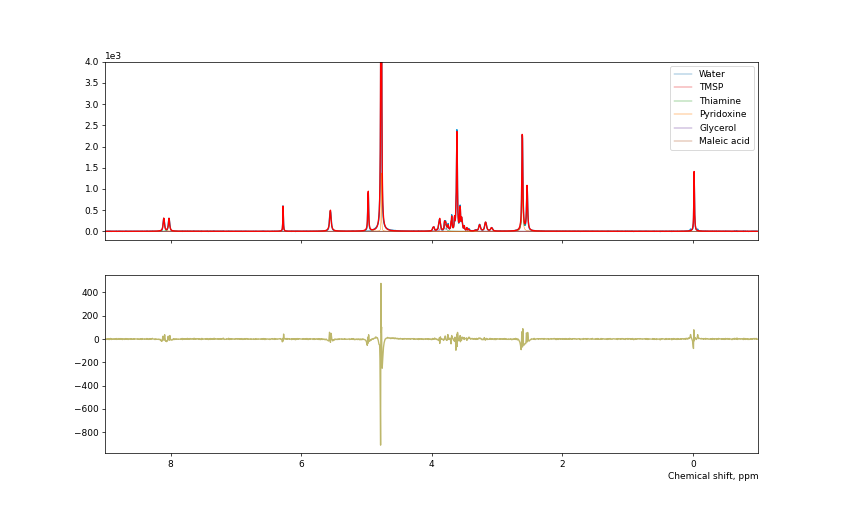

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [24]:
# Select the Datum
dat = wsp[1,3]

# Evaluate to get the values of amplitudes without recomputing them (set autoKeys=[])
dat.evaluate(autoKeys=[], frqBlkIds=[0], returnSignals=True)

# Plot the spectrum and the residual
fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
dat.plot(ax_main=ax[0], ax_residual=ax[1], showRanges=None, showComponents=True)
ax[0].set_xlim(9.0, -1.0)
ax[0].set_ylim(-200, 4000)
fig.show()

# Save the figure
fig.savefig('image.eps', format='eps')
fig.savefig('image.pdf', format='pdf')